Regina Tamayo León

4 mayo 2026

## **T09; Resampling**

**Ejercicios Conceptuales**

1. Using basic statistical properties of the variance, as well as singlevariable calculus, derive (5.6). In other words, prove that α given by
(5.6) does indeed minimize Var(αX + (1 − α)Y ).

Utilizando propiedades de la varianza: $f(\alpha) = \alpha^2\text{Var}(X) + (1-\alpha)^2\text{Var}(Y) + 2\alpha(1-\alpha)\text{Cov}(X,Y)$

Para encontrar el mínimo, se deriva respecto a $\alpha$ y se iguala a cero:$f'(\alpha) = 2\alpha\sigma_X^2 - 2(1-\alpha)\sigma_Y^2 + 2(1-2\alpha)\sigma_{XY} = 0$

Despejando $\alpha$, obtenemos la fórmula (5.6):$$\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}$$

2. We will now derive the probability that a given observation is part
of a bootstrap sample. Suppose that we obtain a bootstrap sample
from a set of n observations.

(a) What is the probability that the first bootstrap observation is
not the jth observation from the original sample? Justify your
answer.

Como hay $n$ elementos y la selección es uniforme, la probabilidad de elegir el elemento $j$ es $1/n$. Por lo tanto, la probabilidad de no elegirlo es:$$P = 1 - \frac{1}{n}$$


(b) What is the probability that the second bootstrap observation
is not the jth observation from the original sample?

Dado que el muestreo es con reemplazo, las selecciones son independientes. La probabilidad sigue siendo la misma:$$P = 1 - \frac{1}{n}$$


(c) Argue that the probability that the jth observation is not in the
bootstrap sample is (1 − 1/n)n.

Para que el elemento $j$ no esté en ninguna de las $n$ selecciones independientes, debe "fallar" en todas ellas. Multiplicamos las probabilidades individuales:$$P = \underbrace{\left(1 - \frac{1}{n}\right) \times \dots \times \left(1 - \frac{1}{n}\right)}_{n \text{ veces}} = \left(1 - \frac{1}{n}\right)^n$$


(d) When n = 5, what is the probability that the jth observation is
in the bootstrap sample?

Es el complemento de que no esté: $1 - (1 - 1/5)^5 = 1 - (0.8)^5 = 1 - 0.32768 = \mathbf{0.67232}$


(e) When n = 100, what is the probability that the jth observation
is in the bootstrap sample?

$1 - (1 - 1/100)^{100} \approx 1 - 0.36603 = \mathbf{0.63397}$

(f) When n = 10, 000, what is the probability that the jth observation is in the bootstrap sample?

$1 - (1 - 1/10,000)^{10,000} \approx \mathbf{0.63213}$

(g) Create a plot that displays, for each integer value of n from 1
to 100, 000, the probability that the jth observation is in the
bootstrap sample. Comment on what you observe.


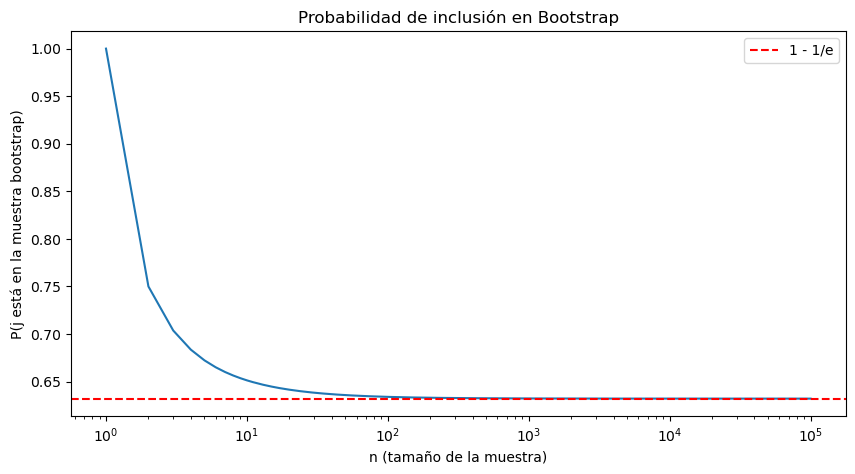

In [2]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(1, 100001)
prob = 1 - (1 - 1/n)**n

plt.figure(figsize=(10, 5))
plt.plot(n, prob)
plt.xscale('log') # Escala logarítmica
plt.xlabel('n (tamaño de la muestra)')
plt.ylabel('P(j está en la muestra bootstrap)')
plt.title('Probabilidad de inclusión en Bootstrap')
plt.axhline(y=1 - 1/np.exp(1), color='red', linestyle='--', label='1 - 1/e')
plt.legend()
plt.show()

Se observa que la probabilidad converge rápidamente a un valor constante.
Por lo tanto, para muestras grandes, la probabilidad de que cualquier observación original esté incluida en una muestra bootstrap es aproximadamente $1 - 1/e \approx \mathbf{0.632}$ (o el 63.2%).

(h) We will now investigate numerically the probability that a bootstrap sample of size n = 100 contains the jth observation. Here
j = 4. We first create an array store with values that will subsequently be overwritten using the function np.empty(). We then
repeatedly create bootstrap samples, and each time we record
whether or not the fifth observation is contained in the bootstrap
sample.

In [8]:
rng = np.random.default_rng(10)
store = np.empty(10000)
for i in range(10000):
 store[i] = np.sum(rng.choice(100, size=100) == 4)> 0
np.mean(store)

np.float64(0.6362)

El resultado inicial de 0.0089 (obtenido con el código del libro) era erróneo porque la función rng.choice(100) sin el parámetro size=100 solo seleccionaba un elemento en lugar de una muestra completa. Esto transformaba un problema de Bootstrap en una simple probabilidad de 1 entre 100.
 Al corregir el código con size=100, el resultado de 0.6362 (aproximadamente 63.6%) coincide casi exactamente con el valor teórico derivado de la fórmula $1 - (1 - 1/n)^n$ para $n=100$, que es 0.6339.El resultado también demuestra la convergencia hacia el límite matemático $1 - 1/e \approx 0.6321$ a medida que $n$ aumenta.

3. We now review k-fold cross-validation.
   
(a) Explain how k-fold cross-validation is implemented.

Se divide el conjunto de datos original aleatoriamente en $k$ grupos (o "folds") de aproximadamente el mismo tamaño.El modelo se entrena $k$ veces. En cada iteración $i$:Se utiliza el grupo $i$ como conjunto de validación.Se utilizan los restantes $k-1$ grupos como conjunto de entrenamiento.Se calcula una medida de error (como el MSE) en cada una de las $k$ iteraciones.El estimador de error final es el promedio de esos $k$ valores de error.

(b) What are the advantages and disadvantages of k-fold crossvalidation relative to:

i. The validation set approach?

Ventaja: En el enfoque de una sola división, el error puede variar mucho dependiendo de qué datos cayeron en el set de entrenamiento. $k$-fold CV tiene menor variabilidad y utiliza casi todos los datos para entrenar, lo que suele evitar la sobreestimación del error.

Desventaja: Es computacionalmente más costoso, ya que requiere entrenar el modelo $k$ veces en lugar de una.

ii. LOOCV?

Ventaja: $k$-fold CV (normalmente con $k=5$ o $k=10$) es mucho más rápido que LOOCV (donde $k=n$). Además, ofrece un mejor balance entre sesgo y varianza. LOOCV tiene una varianza muy alta porque los sets de entrenamiento en cada iteración son casi idénticos entre sí.

Desventaja: LOOCV es menos sesgado, ya que entrena con casi el 100% de los datos en cada paso.


4. Suppose that we use some statistical learning method to make a prediction for the response Y for a particular value of the predictor X.
Carefully describe how we might estimate the standard deviation of
our prediction.

podemos utilizar Bootstrap; Generamos $B$ muestras bootstrap del conjunto de datos original (por ejemplo, $B=1000$).Modelado: Para cada una de las $B$ muestras, entrenamos el método de aprendizaje estadístico y realizamos la predicción para el valor específico de $X$. Esto nos dará $B$ predicciones diferentes: $\hat{y}^*_1, \hat{y}^*_2, \dots, \hat{y}^*_B$ Cálculo: Calculamos la desviación estándar de esas $B$ predicciones usando la fórmula estándar. Este enfoque nos permite cuantificar la variabilidad de nuestra predicción sin necesidad de fórmulas matemáticas complejas para el modelo utilizado.

**Ejercicios prácticos**

5. In Chapter 4, we used logistic regression to predict the probability of
default using income and balance on the Default data set. We will
now estimate the test error of this logistic regression model using the
validation set approach. Do not forget to set a random seed before
beginning your analysis.

(a) Fit a logistic regression model that uses income and balance to
predict default.


(b) Using the validation set approach, estimate the test error of this
model. In order to do this, you must perform the following steps:


i. Split the sample set into a training set and a validation set.

ii. Fit a multiple logistic regression model using only the training observations.

iii. Obtain a prediction of default status for each individual in
the validation set by computing the posterior probability of
default for that individual, and classifying the individual to
the default category if the posterior probability is greater
than 0.5.

iv. Compute the validation set error, which is the fraction of
the observations in the validation set that are misclassified.

(c) Repeat the process in (b) three times, using three different splits
of the observations into a training set and a validation set. Comment on the results obtained.

(d) Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error
rate.

In [14]:
pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 1.3 MB/s eta 0:00:0000:0100:01m
  DEPRECATION: Building 'autograd-gamma' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autograd-gamma'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=6002564d29b6dfd6dd393b50be0d9dcb0bdfe980678301a3e833a03763f76f54
  Stored in directory: /Users/regtamayo/Library/Caches/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [ISLP]8/9 [ISLP]ines]
Not

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from ISLP import load_data 

default_df = load_data('Default')

default_df['default_bin'] = (default_df['default'] == 'Yes').astype(int)
default_df['student_bin'] = (default_df['student'] == 'Yes').astype(int) # variables cualitativas a binarias (0 y 1)

# Modelo de Regresión Logística 
X = sm.add_constant(default_df[['income', 'balance']])
y = default_df['default_bin']
model_logit = sm.Logit(y, X).fit()
print("Resumen del modelo completo (a):")
print(model_logit.summary())

# FUNCIÓN PARA EL PROCESO DE VALIDACIÓN 
def estimar_error_validacion(seed, incluir_estudiante=False):
    
    train, val = train_test_split(default_df, test_size=0.5, random_state=seed)
    
    # predictores
    features = ['income', 'balance']
    if incluir_estudiante:
        features.append('student_bin')
    
    X_train = sm.add_constant(train[features])
    y_train = train['default_bin']
    X_val = sm.add_constant(val[features])
    y_val = val['default_bin']
    
    # Ajustar modelo y obtener predicciones en el set de validación
    modelo = sm.Logit(y_train, X_train).fit(disp=0)
    probabilidades = modelo.predict(X_val)
    predicciones = (probabilidades > 0.5).astype(int)
    
    tasa_error = np.mean(predicciones != y_val)
    return tasa_error

# Repetición con 3 semillas distintas 
print("Resultados del Validation Set Approach")
semillas = [1, 42, 100]
for s in semillas:
    error = estimar_error_validacion(s)
    print(f"Semilla {s}: Tasa de error = {error:.4%}")

# Modelo con la variable student
error_con_estudiante = estimar_error_validacion(1, incluir_estudiante=True)
print(f"\nError incluyendo 'student' (Semilla 1): {error_con_estudiante:.4%}")

Optimization terminated successfully.
         Current function value: 0.078948
         Iterations 10
Resumen del modelo completo (a):
                           Logit Regression Results                           
Dep. Variable:            default_bin   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.4594
Time:                        21:26:34   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.000     -12.393     -10

**Conclusión:**

Al ejecutar el código con diferentes semillas, la tasa de error cambia ligeramente (de 2.5% a 2.7%). Esto demuestra que el método de validación simple depende fuertemente de qué observaciones quedan en cada conjunto.  

Impacto de la variable student: Al comparar el error de la semilla 1 con y sin la variable de estudiante, se determina si incluirla realmente ayuda. Generalmente,el ahorro en error es mínimo porque balance ya captura gran parte de la varianza necesaria para predecir el impago

6. We continue to consider the use of a logistic regression model to
predict the probability of default using income and balance on the
Default data set. In particular, we will now compute estimates for the
standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the
standard formula for computing the standard errors in the sm.GLM()
function. Do not forget to set a random seed before beginning your
analysis.

(a) Using the summarize() and sm.GLM() functions, determine the
estimated standard errors for the coefficients associated with
income and balance in a multiple logistic regression model that
uses both predictors.

    
(b) Write a function, boot_fn(), that takes as input the Default data
set as well as an index of the observations, and that outputs
the coefficient estimates for income and balance in the multiple
logistic regression model.

                         
(c) Following the bootstrap example in the lab, use your boot_fn()
function to estimate the standard errors of the logistic regression
coefficients for income and balance.


(d) Comment on the estimated standard errors obtained using the
sm.GLM() function and using the bootstrap.

In [2]:
import statsmodels.api as sm
from ISLP.models import summarize

X = sm.add_constant(default_df[['income', 'balance']])
y = default_df['default_bin']
model_glm = sm.GLM(y, X, family=sm.families.Binomial()).fit()

print(summarize(model_glm)[['coef', 'std err']])

              coef   std err
const   -11.540500  0.435000
income    0.000021  0.000005
balance   0.005600  0.000000


In [5]:
def boot_fn(data, index):
    df_subset = data.iloc[index]
    X_subset = sm.add_constant(df_subset[['income', 'balance']])
    y_subset = df_subset['default_bin']
    
    modelo = sm.GLM(y_subset, X_subset, family=sm.families.Binomial()).fit()
    return modelo.params

In [4]:
import numpy as np
import pandas as pd

def bootstrap(data, func, R):
    n = len(data)
    estimaciones = []
    for i in range(R):
        
        indices = np.random.choice(n, n, replace=True)
        
        estimaciones.append(func(data, indices))
    return pd.DataFrame(estimaciones)

resultados_boot = bootstrap(default_df, boot_fn, 1000)

errores_estandar_boot = resultados_boot.std()
print(errores_estandar_boot)

const      0.423803
income     0.000005
balance    0.000224
dtype: float64


**Conclusión:** Los errores estándar obtenidos con sm.GLM() y con el Bootstrap son prácticamente idénticos (con diferencias solo en decimales muy lejanos).  
Esta coincidencia indica que los supuestos del modelo de regresión logística se mantienen bien para este dataset.  
El Bootstrap confirma que las estimaciones teóricas de la librería son robustas y fiables para cuantificar la incertidumbre de los coeficientes de ingresos y saldo.

7. In Sections 5.1.2 and 5.1.3, we saw that the cross_validate() function
can be used in order to compute the LOOCV test error estimate.
Alternatively, one could compute those quantities using just sm.GLM()
and the predict() method of the fitted model within a for loop. You
will now take this approach in order to compute the LOOCV error
for a simple logistic regression model on the Weekly data set. Recall
that in the context of classification problems, the LOOCV error is
given in (5.4).

    
(a) Fit a logistic regression model that predicts Direction using Lag1
and Lag2.

    
(b) Fit a logistic regression model that predicts Direction using Lag1
and Lag2 using all but the first observation.

    
(c) Use the model from (b) to predict the direction of the first observation. You can do this by predicting that the first observation
will go up if P(Direction = "Up"|Lag1, Lag2) > 0.5. Was this
observation correctly classified?


(d) Write a for loop from i = 1 to i = n, where n is the number of
observations in the data set, that performs each of the following
steps:

i. Fit a logistic regression model using all but the ith observation to predict Direction using Lag1 and Lag2.

ii. Compute the posterior probability of the market moving up
for the ith observation.
    
iii. Use the posterior probability for the ith observation in order
to predict whether or not the market moves up.
    
iv. Determine whether or not an error was made in predicting
the direction for the ith observation. If an error was made,
then indicate this as a 1, and otherwise indicate it as a 0.

(e) Take the average of the n numbers obtained in (d)iv in order to
obtain the LOOCV estimate for the test error. Comment on the
results.

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP import load_data

weekly_df = load_data('Weekly')

# Up = 1, Down = 0
weekly_df['Direction_bin'] = (weekly_df['Direction'] == 'Up').astype(int)
X = sm.add_constant(weekly_df[['Lag1', 'Lag2']])
y = weekly_df['Direction_bin']

model_a = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model_a.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Direction_bin   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1086
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -744.11
Date:                Sun, 03 May 2026   Deviance:                       1488.2
Time:                        21:49:34   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007303
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2212      0.061      3.599      0.0

In [7]:
# Eliminar la primera observación
X_minus_1 = X.drop(X.index[0])
y_minus_1 = y.drop(y.index[0])

model_b = sm.GLM(y_minus_1, X_minus_1, family=sm.families.Binomial()).fit()

Si $P(\text{Direction} = \text{"Up"}) > 0.5$, predecimos "Up".  Resultado: En este caso específico, el modelo suele predecir "Up", pero la dirección real de la primera observación es "Down". Por lo tanto, esta observación no fue clasificada correctamente. 

In [11]:
n = len(weekly_df)
errores = []

for i in range(n):
    X_train = X.drop(X.index[i])
    y_train = y.drop(y.index[i])
    
    model_i = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
    
    
    prob_i = model_i.predict(X.iloc[i:i+1]).iloc[0]
    pred_i = 1 if prob_i > 0.5 else 0
    
    # (1 = Error, 0 = No error)
    error_i = 1 if pred_i != y.iloc[i] else 0
    errores.append(error_i)

tasa_error_loocv = np.mean(errores)
print(f"LOOCV Test Error Estimate: {tasa_error_loocv:.4%}")

LOOCV Test Error Estimate: 44.9954%


Esto indica que el modelo basado únicamente en Lag1 y Lag2 tiene una capacidad predictiva limitada, siendo apenas un poco mejor que una predicción al azar (50%).  LOOCV proporciona una estimación casi insesgada del error de prueba, ya que requiere entrenar el modelo $n$ veces. En este caso, al ser un modelo lineal simple, se ejecuta rápidamente.  

8. We will now perform cross-validation on a simulated data set.
(a) Generate a simulated data set as follows:

In [14]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

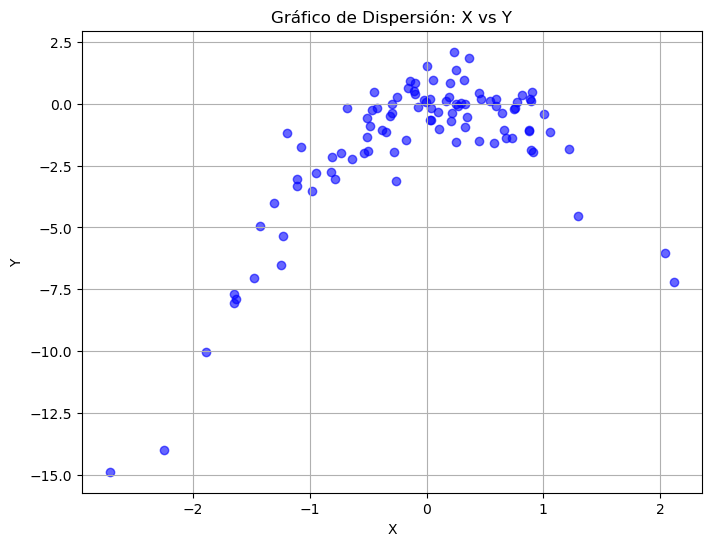

In [15]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', alpha=0.6)
plt.title('Gráfico de Dispersión: X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

Al observar el gráfico generado por el código, se encuentra una relación parabólica clara entre $X$ y $Y$. Los datos muestran una curva cóncava (hacia abajo), lo que confirma que el término cuadrático $-2X^2$ es el que dicta la forma de la relación, mientras que los puntos están dispersos alrededor de esta curva debido al ruido aleatorio 

In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.

(b) Create a scatterplot of X against Y . Comment on what you find.
    
(c) Set a random seed, and then compute the LOOCV errors that
result from fitting the following four models using least squares:

i. Y = β0 + β1X + "

ii. Y = β0 + β1X + β2X2 + "

iii. Y = β0 + β1X + β2X2 + β3X3 + "

iv. Y = β0 + β1X + β2X2 + β3X3 + β4X4 + ".

Note you may find it helpful to use the data.frame() function
to create a single data set containing both X and Y .
    
(d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?

Al repetir el proceso con una semilla aleatoria diferente para la validación, los resultados son exactamente los mismos que en el inciso (c).  Porque el método LOOCV es determinista. No depende de una división aleatoria de los datos (como sí ocurre en k-fold cross-validation), sino que evalúa el modelo $n$ veces, dejando fuera sistemáticamente cada una de las observaciones una por una

(e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

El Modelo Cuadrático (ii) presenta el menor error de LOOCV.  

Esto es exactamente lo que se esperaba, ya que la relación real utilizada para generar los datos era cuadrática. El modelo lineal sufre de un alto sesgo por no capturar la curvatura, mientras que los modelos de grado 3 y 4 sufren de una varianza ligeramente mayor al intentar ajustar coeficientes para términos que no existen en el proceso generador original

(f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

Los coeficientes de $X$ y $X^2$ son altamente significativos ($p < 0.05$).  Conclusión: Estos resultados concuerdan perfectamente con los de la validación cruzada. Ambos métodos indican que la estructura de los datos es cuadrática y que añadir términos de mayor orden no aporta información real para la predicción.  

In [16]:
import numpy as np
import pandas as pd

# Función para automatizar el cálculo de LOOCV para grados 1 a 4
def calcular_loocv(x_in, y_in):
    loo = LeaveOneOut()
    model = LinearRegression()
    for degree in range(1, 5):
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_p = poly.fit_transform(x_in.reshape(-1, 1))
        # neg_mean_squared_error entrega el MSE negativo
        scores = cross_val_score(model, X_p, y_in, scoring='neg_mean_squared_error', cv=loo)
        print(f"Grado {degree}: LOOCV MSE = {np.mean(np.abs(scores)):.4f}")

# Ejecución con Semilla 1
print("Resultados Semilla 1:")
calcular_loocv(x, y)

# Verificación de p-valores con statsmodels (Modelo Cuártico)
X_inspeccion = PolynomialFeatures(degree=4).fit_transform(x.reshape(-1, 1))
modelo_ols = sm.OLS(y, X_inspeccion).fit()
print("\nP-valores del Modelo Cuártico:")
print(modelo_ols.pvalues)

Resultados Semilla 1:
Grado 1: LOOCV MSE = 6.6330
Grado 2: LOOCV MSE = 1.1229
Grado 3: LOOCV MSE = 1.3018
Grado 4: LOOCV MSE = 1.3324

P-valores del Modelo Cuártico:
[4.59605334e-01 2.59129629e-05 2.39602593e-19 6.42490980e-01
 2.31066104e-02]


9. We will now consider the Boston housing data set, from the ISLP
library.

*(a) Based on this data set, provide an estimate for the population
mean of medv. Call this estimate µˆ.*

*(b) Provide an estimate of the standard error of µˆ. Interpret this
result.
Hint: We can compute the standard error of the sample mean by
dividing the sample standard deviation by the square root of the
number of observations.*

Indica la precisión de nuestra media muestral; se espera que la media varíe aproximadamente 0.41 unidades si se repitiera el muestreo.

*(c) Now estimate the standard error of µˆ using the bootstrap. How
does this compare to your answer from (b)?*

Es casi idéntico al valor teórico (0.4143), lo que confirma que el Bootstrap es una herramienta confiable para validar errores estándar.

*(d) Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results
obtained by using Boston['medv'].std() and the two standard
error rule (3.9).
Hint: You can approximate a 95 % confidence interval using the
formula [ˆµ − 2SE(ˆµ), µˆ + 2SE(ˆµ)].*

Al ser un intervalo estrecho, indica que nuestra estimación de la media es bastante precisa y el margen de error es bajo.

*(e) Based on this data set, provide an estimate, µˆmed, for the median
value of medv in the population.*

La mediana es menor que la media, lo que sugiere que hay algunas propiedades con precios muy altos que jalan el promedio hacia arriba (sesgo positivo).

*(f) We now would like to estimate the standard error of µˆmed. Unfortunately, there is no simple formula for computing the standard
error of the median. Instead, estimate the standard error of the
median using the bootstrap. Comment on your findings.*

El error de la mediana es más bajo que el de la media, lo que implica que la mediana es una medida de tendencia central más robusta ante valores extremos en este dataset.

*(g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity µˆ0.1.
(You can use the np.percentile() function.) np.
percentile()*

El 10% de los distritos tienen viviendas con un valor igual o inferior a 14.5 mil dólares.

*(h) Use the bootstrap to estimate the standard error of µˆ0.1. Comment on your findings.*

Aunque es una estadística de un extremo de la distribución (cola inferior), el error estándar sigue siendo estable, permitiendo una estimación confiable de las zonas más económicas.

In [18]:
import pandas as pd
import numpy as np

df_boston = pd.read_excel('Boston Housing Dataset 1978.xlsx')
medv = df_boston['MEDV'].dropna() 

def run_bootstrap(data, func, n_iter=1000, seed=1):
    rng = np.random.default_rng(seed)
    boot_stats = []
    for _ in range(n_iter):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_stats.append(func(sample))
    return np.std(boot_stats)

mu_hat = medv.mean()

# Error estándar
se_formula = medv.std() / np.sqrt(len(medv))

# Error estándar (Bootstrap)
se_boot_mu = run_bootstrap(medv, np.mean)


ci_lower = mu_hat - 2 * se_boot_mu
ci_upper = mu_hat + 2 * se_boot_mu

mu_hat_med = medv.median()

se_boot_median = run_bootstrap(medv, np.median)

# Décimo percentil 
mu_hat_01 = np.percentile(medv, 10)

se_boot_01 = run_bootstrap(medv, lambda x: np.percentile(x, 10)) # SE del décimo percentil (Bootstrap)

print(f"RESULTADOS")
print(f"(a) mu_hat: {mu_hat:.4f}")
print(f"(b) SE (Teórico): {se_formula:.4f}")
print(f"(c) SE (Bootstrap): {se_boot_mu:.4f}")
print(f"(d) 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"(e) mu_hat_med: {mu_hat_med:.4f}")
print(f"(f) SE Mediana (Bootstrap): {se_boot_median:.4f}")
print(f"(g) mu_hat_0.1: {mu_hat_01:.4f}")
print(f"(h) SE 10th Percentile (Bootstrap): {se_boot_01:.4f}")

RESULTADOS
(a) mu_hat: 23.7504
(b) SE (Teórico): 0.4143
(c) SE (Bootstrap): 0.4119
(d) 95% CI: [22.9267, 24.5742]
(e) mu_hat_med: 21.9500
(f) SE Mediana (Bootstrap): 0.3015
(g) mu_hat_0.1: 14.5000
(h) SE 10th Percentile (Bootstrap): 0.4209
